In [11]:
# ═══ SPARC4 · AU Mic b · trânsito parcial · 2026-07-19 ══════════════════════
# Versão simples: fotometria diferencial -> linha de base -> modelo batman.
# Célula 1: tudo que se ajusta fica aqui.
import os

BASE   = r"C:/Users/paola/Desktop/Doutorado/Codigos-doc/Flares-/novo_homepage/Sparc4-data"
NIGHT  = "20260719"   # noite com o trânsito parcial de AU Mic b
OUTDIR = os.path.join(BASE, "resultados_transitos")

NIGHT_DIR   = os.path.join(BASE, "data", NIGHT)
NIGHT_LABEL = f"{NIGHT[:4]}-{NIGHT[4:6]}-{NIGHT[6:]}"
os.makedirs(OUTDIR, exist_ok=True)

# ── fotometria ───────────────────────────────────────────────────────────────
CHANNELS = [1, 2, 3, 4]
BANDS    = {1: "g", 2: "r", 3: "i", 4: "z"}
BEAM     = "S+N"        # soma dos feixes: cancela a modulação da lâmina
APER     = 8            # raio da abertura, em pixels
NCOMPS   = 3            # nº de comparações (as mais brilhantes depois do alvo)
COMPS    = {}           # p.ex. {1: [1, 3, 2]} força as comparações de um canal
BIN_MIN  = 5.0          # binning, em minutos
NSIG_FLARE = 3.0        # corta excursões positivas (flares) acima deste nível

# ── planeta: AU Mic b ────────────────────────────────────────────────────────
# Efeméride do seu próprio MCMC dos setores 1, 27 e 95 (mcmc_auMic_b_ephx1.npz),
# convertida de BTJD para BJD_TDB. Geometria de Plavchan+2020 / Martioli+2021.
T0_TDB  = 2458330.3864186   # BJD_TDB (= 1330.3864186 BTJD)
T0_ERR  = 0.00072           # d  (~1.0 min)
PER     = 8.4631566         # d
PER_ERR = 0.0000050         # d  (~0.4 s)

RP_RS  = 0.0496        # Rp/R*
A_RS   = 19.1            # a/R*
INC    = 89.5            # graus
ECC, W = 0.0, 90.0

# escurecimento de bordo quadrático por banda (Teff 3700 K, logg 4.5) —
# valores aproximados de tabelas de Claret para o sistema SDSS
LDC = {"g": [0.62, 0.28], "r": [0.55, 0.32],
       "i": [0.40, 0.33], "z": [0.30, 0.32]}

# ── o que fazer com o instante do trânsito ───────────────────────────────────
TC_MANUAL = None    # BJD_TDB do centro, se você souber; None = usa a efeméride
MODO      = "auto"  # "auto"    -> efeméride (ou TC_MANUAL), com busca fina em ±DT_MAX
                    # "busca"   -> varre a noite inteira procurando o melhor Tc
DT_MAX    = 30.0    # busca fina, em minutos

# ── linha de base ────────────────────────────────────────────────────────────
BASE_ORD  = 1       # ordem do polinômio no tempo (1 = reta)
USA_MASSA = True    # inclui termo linear em (massa de ar - 1)

print(f"noite {NIGHT_LABEL}  ->  {NIGHT_DIR}")
print(f"AU Mic b: P = {PER} d | Rp/R* = {RP_RS} -> profundidade "
      f"~ {RP_RS**2*1e3:.2f} ppt (sem escurecimento de bordo)")



noite 2026-07-19  ->  C:/Users/paola/Desktop/Doutorado/Codigos-doc/Flares-/novo_homepage/Sparc4-data\data\20260719
AU Mic b: P = 8.4631566 d | Rp/R* = 0.0496 -> profundidade ~ 2.46 ppt (sem escurecimento de bordo)


In [12]:
# ═══ 2 · fotometria diferencial simples ═════════════════════════════════════
# alvo / soma das comparações, tempo em BJD_TDB, flares cortados, binado.
import glob, re
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from astropy.io import fits
from astropy.time import Time
from astropy.coordinates import EarthLocation, SkyCoord, AltAz
from scipy.ndimage import median_filter
import astropy.units as u

CORES = {"g": "#3b6ea5", "r": "#3f8f4f", "i": "#c06a2a", "z": "#8b3a5a"}

def le_curva(ch):
    """Lê o produto do canal e devolve t(BJD_TDB), mag(nsrc,nt), emag, índices."""
    arq = sorted(glob.glob(os.path.join(NIGHT_DIR, f"*_s4c{ch}_*_{BEAM}_lc.fits")))[0]
    with fits.open(arq) as h:
        ext = [e.name for e in h if re.search(rf"AP0*{APER}$", e.name or "")][0]
        d, hdr0 = h[ext].data, h[0].header
        src  = np.asarray(d["SRCINDEX"]).astype(int)
        tempo = np.asarray(d["TIME"], float)
        mag, emag = np.asarray(d["MAG"], float), np.asarray(d["EMAG"], float)
        flag = np.asarray(d["FLAG"]) if "FLAG" in d.columns.names else None
    idx, t = np.unique(src), np.unique(tempo)
    lin, col = np.searchsorted(idx, src), np.searchsorted(t, tempo)
    M = np.full((idx.size, t.size), np.nan);  E = np.full_like(M, np.nan)
    M[lin, col], E[lin, col] = mag, emag
    if flag is not None:
        ruim = np.full(M.shape, False);  ruim[lin, col] = np.asarray(flag) != 0
        M[ruim] = np.nan
    return arq, hdr0, t, idx, M, E

def massa_de_ar(t_utc, hdr0):
    local = EarthLocation(lat=hdr0["OBSLAT"] * u.deg, lon=hdr0["OBSLONG"] * u.deg,
                          height=hdr0["OBSALT"] * u.m)
    alvo  = SkyCoord(hdr0["RA"] * u.deg, hdr0["DEC"] * u.deg, frame="icrs")
    tempo = Time(t_utc, format="jd", scale="utc")
    return alvo.transform_to(AltAz(obstime=tempo, location=local)).secz.value

def binar(t, y, e, dt_min):
    k = np.floor((t - t.min()) / (dt_min / 1440)).astype(int)
    tb, yb, eb, nb = [], [], [], []
    for g in np.unique(k):
        m = k == g
        tb.append(t[m].mean());  yb.append(np.mean(y[m]))
        eb.append(np.std(y[m], ddof=1) / np.sqrt(m.sum()) if m.sum() > 1 else e[m][0])
        nb.append(int(m.sum()))
    return map(np.array, (tb, yb, eb, nb))

dados, linhas = {}, []
for ch in CHANNELS:
    arq, hdr0, t_utc, idx, M, E = le_curva(ch)

    # alvo = fonte mais brilhante; comparações = as NCOMPS seguintes
    ordem = idx[np.argsort(np.nanmedian(M, axis=1))]
    alvo  = int(ordem[0])
    comps = COMPS.get(ch, [int(i) for i in ordem[1:1 + NCOMPS]])
    ia = int(np.where(idx == alvo)[0][0])
    ic = [int(np.where(idx == c)[0][0]) for c in comps]

    # razão de fluxos alvo / soma das comparações
    with np.errstate(invalid="ignore", divide="ignore"):
        f_alvo = 10 ** (-0.4 * M[ia])
        f_comp = np.nansum(10 ** (-0.4 * M[ic]), axis=0)
        razao  = f_alvo / f_comp
        e_raz  = razao * 0.4 * np.log(10) * np.hypot(
            E[ia], np.sqrt(np.nansum((10 ** (-0.4 * M[ic]) * E[ic]) ** 2, axis=0)) /
            np.where(f_comp > 0, f_comp, np.nan))
    ok = np.isfinite(razao) & np.isfinite(e_raz)
    t_tdb = Time(t_utc, format="jd", scale="utc").tdb.jd     # BJD_UTC -> BJD_TDB
    t_tdb, razao, e_raz = t_tdb[ok], razao[ok] / np.nanmedian(razao[ok]), e_raz[ok]
    X = massa_de_ar(t_utc[ok], hdr0)

    # flares: tira o que sobe acima de NSIG_FLARE da mediana móvel de 10 min
    n_jan = max(int(round((10 / 1440) / np.median(np.diff(t_tdb)))) | 1, 3)
    resid = razao - median_filter(razao, size=n_jan, mode="nearest")
    sigma = 1.4826 * np.median(np.abs(resid - np.median(resid)))
    limpo = resid < NSIG_FLARE * sigma

    tb, fb, eb, nb = binar(t_tdb[limpo], razao[limpo], e_raz[limpo], BIN_MIN)
    fb = fb / np.median(fb)
    # erro realista do bin: o formal costuma subestimar, então usa-se o maior
    # entre ele e a dispersão entre bins vizinhos (ruído branco efetivo)
    eb = np.maximum(eb, np.std(np.diff(fb)) / np.sqrt(2))
    Xb = np.interp(tb, t_tdb, X)
    dados[ch] = dict(band=BANDS[ch], arq=os.path.basename(arq), alvo=alvo,
                     comps=comps, t=t_tdb, f=razao, X=X, limpo=limpo,
                     tb=tb, fb=fb, eb=eb, nb=nb, Xb=Xb)
    linhas.append(dict(banda=f"{BANDS[ch]}'", alvo=alvo, comps=str(comps),
                       n_fits=int(t_tdb.size), flares=int((~limpo).sum()),
                       n_bins=int(tb.size), erro_bin_ppt=np.mean(eb) * 1e3,
                       ruido_bin_ppt=np.std(np.diff(fb)) / np.sqrt(2) * 1e3))

TSTART = min(d["t"].min() for d in dados.values())
TSTOP  = max(d["t"].max() for d in dados.values())
display(pd.DataFrame(linhas).set_index("banda").style.format(
    {"erro_bin_ppt": "{:.2f}", "ruido_bin_ppt": "{:.2f}"}))
print(f"janela: {TSTART:.6f} .. {TSTOP:.6f} BJD_TDB  ({(TSTOP-TSTART)*24:.2f} h)")
print(f"        {Time(TSTART, format='jd').isot} .. {Time(TSTOP, format='jd').isot} UTC")
print(f"bins de {BIN_MIN:.0f} min · AP{APER:03d} · feixe {BEAM}")



,alvo,comps,n_fits,flares,n_bins,erro_bin_ppt,ruido_bin_ppt
banda,,,,,,,
g',0,"[1, 3, 2]",7039,34,66,1.30,1.30
r',0,"[1, 2, 3]",14077,123,66,1.17,1.16
i',0,"[1, 2, 3]",14077,77,66,2.06,2.06
z',0,"[1, 2, 3]",14075,83,66,2.00,2.00


janela: 2461241.540025 .. 2461241.770711 BJD_TDB  (5.54 h)
        2026-07-20T00:57:38.168 .. 2026-07-20T06:29:49.395 UTC
bins de 5 min · AP008 · feixe S+N


In [14]:
# ═══ 3 · onde cai o trânsito? ═══════════════════════════════════════════════
import numpy as np
from astropy.time import Time

# duração do trânsito pela geometria
bimp = A_RS * np.cos(np.radians(INC))
T14  = PER / np.pi * np.arcsin(np.sqrt(max((1 + RP_RS) ** 2 - bimp ** 2, 0))
                               / (A_RS * np.sin(np.radians(INC))))

E_mid = (0.5 * (TSTART + TSTOP) - T0_TDB) / PER
print(f"AU Mic b: T14 = {T14*24:.2f} h | b = {bimp:.3f}")
print("trânsitos previstos mais próximos desta noite:")
for E in [int(np.floor(E_mid)), int(np.ceil(E_mid))]:
    tc = T0_TDB + E * PER
    dentro = TSTART <= tc <= TSTOP
    print(f"   E={E}: Tc = {tc:.5f} BJD_TDB  ({Time(tc, format='jd').isot} UTC)"
          f"   {'<-- DENTRO da janela' if dentro else ''}")

EPOCH = int(round(E_mid))
TC_EFEM = T0_TDB + EPOCH * PER
TC_ERR  = np.hypot(T0_ERR, EPOCH * PER_ERR)
sobrepoe = (TC_EFEM + T14 / 2 > TSTART) and (TC_EFEM - T14 / 2 < TSTOP)

if TC_MANUAL is not None:
    TC, origem = float(TC_MANUAL), "TC_MANUAL"
elif sobrepoe:
    TC, origem = TC_EFEM, "efeméride"
else:
    TC, origem = 0.5 * (TSTART + TSTOP), "centro da janela (só ponto de partida)"
    if MODO == "auto":
        MODO = "busca"
        print("\nA efeméride não põe trânsito nesta janela -> MODO = 'busca':\n"
              "o ajuste vai varrer a noite inteira procurando o melhor Tc.\n"
              "Se você tem a efeméride certa, corrija T0_TDB/PER na célula 1,\n"
              "ou informe o instante do evento em TC_MANUAL.")

ING, EGR = TC - T14 / 2, TC + T14 / 2
cob = (min(TSTOP, EGR) - max(TSTART, ING)) / T14
print(f"\nTc adotado = {TC:.5f} BJD_TDB   (origem: {origem})")
print(f"modo do ajuste = {MODO}")
print(f"cobertura em torno desse Tc: {cob*100:.0f} % de T14 "
      f"({'parcial' if cob < 0.99 else 'completo'})")



AU Mic b: T14 = 3.51 h | b = 0.167
trânsitos previstos mais próximos desta noite:
   E=343: Tc = 2461233.24913 BJD_TDB  (2026-07-11T17:58:45.039 UTC)   
   E=344: Tc = 2461241.71229 BJD_TDB  (2026-07-20T05:05:41.770 UTC)   <-- DENTRO da janela

Tc adotado = 2461241.71229 BJD_TDB   (origem: efeméride)
modo do ajuste = auto
cobertura em torno desse Tc: 90 % de T14 (parcial)


In [15]:
# ═══ 4 · modelo de trânsito (batman) + linha de base ════════════════════════
# A profundidade entra como um fator de escala do modelo da literatura e é
# resolvida junto com a linha de base num único sistema linear; o instante Tc,
# que é o único parâmetro não-linear, é varrido numa grade.
import numpy as np, pandas as pd, batman

chs, bandas = sorted(dados), [dados[c]["band"] for c in sorted(dados)]

def modelo(t, tc, band, exp_min=BIN_MIN):
    p = batman.TransitParams()
    p.t0, p.per, p.rp, p.a, p.inc = tc, PER, RP_RS, A_RS, INC
    p.ecc, p.w, p.u, p.limb_dark = ECC, W, list(LDC[band]), "quadratic"
    m = batman.TransitModel(p, np.asarray(t, float), supersample_factor=7,
                            exp_time=exp_min / 1440)
    return m.light_curve(p)

# profundidade do modelo da literatura, por banda (com escurecimento de bordo)
_tf   = np.linspace(TC - T14, TC + T14, 2000)
PROF0 = {b: 1 - modelo(_tf, TC, b, 0.5).min() for b in bandas}

def perfil(t, tc, band):
    """0 fora do trânsito, PROF0 no centro."""
    return 1 - modelo(t, tc, band)

def base_design(ch):
    d  = dados[ch]
    tn = (d["tb"] - TC) * 24
    cols = [np.ones_like(tn)] + [tn ** k for k in range(1, BASE_ORD + 1)]
    if USA_MASSA:
        cols.append(d["Xb"] - 1)
    return np.column_stack(cols)

DES = {ch: base_design(ch) for ch in chs}
NB  = DES[chs[0]].shape[1]

def ajusta(tc, com_transito=True):
    """Resolve linha de base (+ escala da profundidade). -> chi2, par, cov, ndof"""
    n   = sum(dados[ch]["tb"].size for ch in chs)
    ncol = len(chs) * NB + (1 if com_transito else 0)
    G, y, w, i0 = np.zeros((n, ncol)), np.zeros(n), np.zeros(n), 0
    for j, ch in enumerate(chs):
        d = dados[ch];  k = d["tb"].size;  sl = slice(i0, i0 + k)
        G[sl, j * NB:(j + 1) * NB] = DES[ch]
        if com_transito:
            G[sl, -1] = -perfil(d["tb"], tc, d["band"])
        y[sl], w[sl] = d["fb"], 1 / d["eb"]
        i0 += k
    Gw, yw = G * w[:, None], y * w
    par, *_ = np.linalg.lstsq(Gw, yw, rcond=None)
    chi2 = float(np.sum((Gw @ par - yw) ** 2))
    return chi2, par, np.linalg.pinv(Gw.T @ Gw), n - ncol

# grade de Tc. No modo busca o centro pode cair FORA da janela (é assim que se
# acha um trânsito parcial no começo ou no fim da noite); exige-se apenas um
# mínimo de pontos dentro do trânsito.
MIN_DENTRO = 6          # nº mínimo de bins dentro do trânsito

if MODO == "busca":
    grade = np.arange(TSTART - T14 / 2, TSTOP + T14 / 2, 2.0 / 1440)
else:
    grade = TC + np.arange(-DT_MAX, DT_MAX + 0.01, 0.5) / 1440

def n_dentro(tc):
    d = dados[chs[0]]
    return int(np.sum(perfil(d["tb"], tc, bandas[0]) > 0.2 * PROF0[bandas[0]]))

vale  = np.array([n_dentro(tc) >= MIN_DENTRO for tc in grade])
chi2s = np.array([ajusta(tc)[0] if v else np.nan for tc, v in zip(grade, vale)])
if not np.any(vale):
    raise RuntimeError("nenhum Tc da grade tem pontos suficientes dentro do trânsito")
TC_FIT = float(grade[np.nanargmin(chi2s)])
deltas = np.array([ajusta(tc)[1][-1] if v else np.nan
                   for tc, v in zip(grade, vale)])

chi2, par, cov, ndof = ajusta(TC_FIT)
esc  = max(chi2 / ndof, 1.0)              # infla erros por causa do ruído correlacionado
delta, e_delta = par[-1], np.sqrt(abs(cov[-1, -1]) * esc)
chi2_sem = ajusta(TC_FIT, com_transito=False)[0]
dchi2 = (chi2_sem - chi2) / esc
nsig  = float(np.sign(delta) * np.sqrt(max(dchi2, 0)))

bases = {ch: DES[ch] @ par[j * NB:(j + 1) * NB] for j, ch in enumerate(chs)}
prof  = {b: delta * PROF0[b] for b in bandas}

print(f"Tc ajustado = {TC_FIT:.5f} BJD_TDB  "
      f"({Time(TC_FIT, format='jd').isot} UTC)")
if origem == "efeméride":
    print(f"O-C = {(TC_FIT - TC_EFEM)*1440:+.1f} min "
          f"(efeméride: ± {TC_ERR*1440:.1f} min)")
print(f"χ²/ndof = {chi2/ndof:.2f}   Δχ² = {dchi2:.1f}  ->  {nsig:+.1f}σ")
print(f"escala da profundidade: delta = {delta:.2f} ± {e_delta:.2f} "
      f"(1.00 = profundidade da literatura)\n")

tab = pd.DataFrame([{
    "banda": f"{b}'",
    "prof. esperada (ppt)": PROF0[b] * 1e3,
    "prof. medida (ppt)": prof[b] * 1e3,
    "sigma (ppt)": e_delta * PROF0[b] * 1e3,
    "rms resíduo (ppt)": np.std(dados[ch]["fb"] - bases[ch]
                                + delta * perfil(dados[ch]["tb"], TC_FIT, b)) * 1e3,
} for ch, b in zip(chs, bandas)]).set_index("banda")
display(tab.style.format("{:.2f}"))

if nsig > 3:
    veredito = "sinal com forma de trânsito"
elif nsig < -3:
    veredito = "CLAREAMENTO no lugar do trânsito (sistemática, não trânsito)"
else:
    veredito = "sem detecção significativa"
lim = 3 * e_delta * PROF0[bandas[0]] * 1e3
print(f"veredito: {veredito}")
print(f"referência — 3σ da profundidade em {bandas[0]}': {lim:.2f} ppt "
      f"(literatura: {PROF0[bandas[0]]*1e3:.2f} ppt)")

# onde caiu o melhor Tc em relação à noite observada
if TC_FIT < TSTART:
    onde = f"{(TSTART-TC_FIT)*24*60:.0f} min ANTES do início da noite (só o egresso)"
elif TC_FIT > TSTOP:
    onde = f"{(TC_FIT-TSTOP)*24*60:.0f} min DEPOIS do fim da noite (só o ingresso)"
else:
    onde = (f"dentro da janela, a {(TC_FIT-TSTART)*24:.1f} h do início "
            f"e {(TSTOP-TC_FIT)*24:.1f} h do fim")
print(f"posição do Tc ajustado: {onde}")

if MODO == "busca":
    print(f"\nCUIDADO com o Δχ² acima: no modo 'busca' o Tc fica livre na noite")
    print(f"inteira, e um trânsito de {T14*24:.1f} h ajustado numa janela de "
          f"{(TSTOP-TSTART)*24:.1f} h com")
    print("linha de base livre é degenerado com a variabilidade da estrela — o")
    print("número não é a significância de uma detecção (procurou-se em muitos")
    print("instantes). Serve como candidato: para confirmar, ponha a efeméride")
    print("certa em T0_TDB/PER, ou fixe o instante do evento em TC_MANUAL.")



Tc ajustado = 2461241.71680 BJD_TDB  (2026-07-20T05:12:11.770 UTC)
O-C = +6.5 min (efeméride: ± 2.7 min)
χ²/ndof = 4.00   Δχ² = 4.1  ->  -2.0σ
escala da profundidade: delta = -0.56 ± 0.27 (1.00 = profundidade da literatura)



,prof. esperada (ppt),prof. medida (ppt),sigma (ppt),rms resíduo (ppt)
banda,,,,
g',3.26,-1.82,0.89,2.05
r',3.20,-1.78,0.87,1.97
i',3.01,-1.68,0.82,5.10
z',2.89,-1.61,0.79,3.95


veredito: sem detecção significativa
referência — 3σ da profundidade em g': 2.68 ppt (literatura: 3.26 ppt)
posição do Tc ajustado: dentro da janela, a 4.2 h do início e 1.3 h do fim


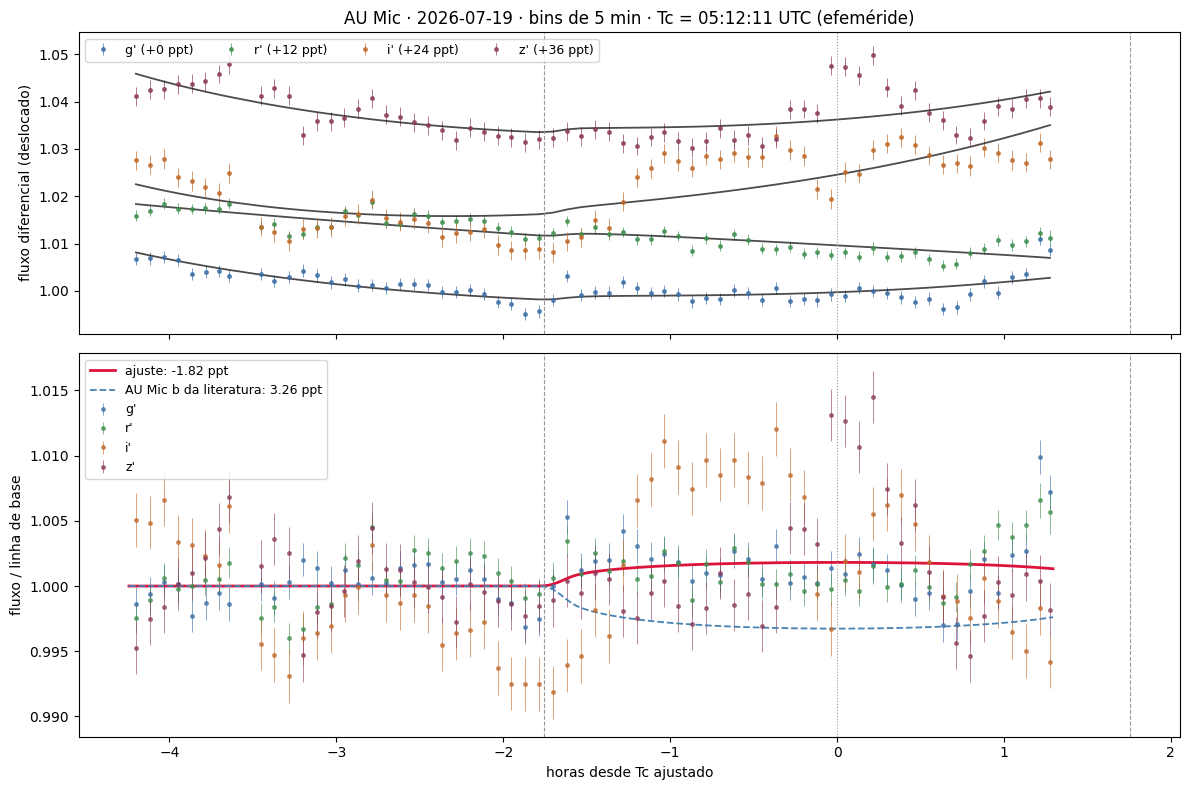

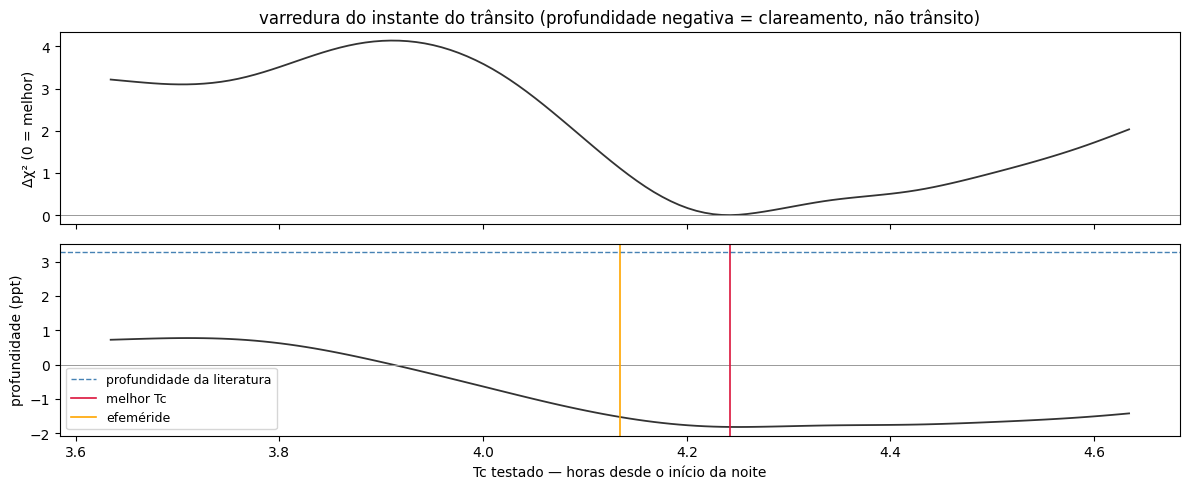

gravado: C:/Users/paola/Desktop/Doutorado/Codigos-doc/Flares-/novo_homepage/Sparc4-data\resultados_transitos\aumic_b_simples_20260719_ep344_curvas_binadas.csv
         C:/Users/paola/Desktop/Doutorado/Codigos-doc/Flares-/novo_homepage/Sparc4-data\resultados_transitos\aumic_b_simples_20260719_ep344_resumo.txt


In [16]:
# ═══ 5 · figura ═════════════════════════════════════════════════════════════
import numpy as np, matplotlib.pyplot as plt
from astropy.time import Time

tg = np.linspace(TSTART, TSTOP, 1200)
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                        gridspec_kw=dict(height_ratios=[1.1, 1.4]))

for j, ch in enumerate(chs):
    d, b = dados[ch], bandas[j]
    x = (d["tb"] - TC_FIT) * 24
    axs[0].errorbar(x, d["fb"] + j * 0.012, d["eb"], fmt=".", ms=5, lw=.6,
                    alpha=.8, color=CORES[b], label=f"{b}' (+{j*12:.0f} ppt)")
    axs[0].plot(x, bases[ch] - delta * perfil(d["tb"], TC_FIT, b) + j * 0.012,
                "-", lw=1.3, color="k", alpha=.7)
    axs[1].errorbar(x, d["fb"] / bases[ch], d["eb"], fmt=".", ms=5, lw=.6,
                    alpha=.7, color=CORES[b], label=f"{b}'")

axs[1].plot((tg - TC_FIT) * 24, 1 - delta * perfil(tg, TC_FIT, bandas[0]),
            "-", lw=2, color="crimson",
            label=f"ajuste: {prof[bandas[0]]*1e3:.2f} ppt")
axs[1].plot((tg - TC_FIT) * 24, 1 - perfil(tg, TC_FIT, bandas[0]),
            "--", lw=1.3, color="steelblue",
            label=f"AU Mic b da literatura: {PROF0[bandas[0]]*1e3:.2f} ppt")
for ax in axs:
    ax.axvline(-T14 / 2 * 24, color="0.6", lw=.8, ls="--")
    ax.axvline(+T14 / 2 * 24, color="0.6", lw=.8, ls="--")
    ax.axvline(0, color="0.6", lw=.8, ls=":")
axs[0].set_ylabel("fluxo diferencial (deslocado)")
axs[0].legend(ncol=4, fontsize=9)
axs[0].set_title(f"AU Mic · {NIGHT_LABEL} · bins de {BIN_MIN:.0f} min · "
                 f"Tc = {Time(TC_FIT, format='jd').isot[11:19]} UTC ({origem})")
axs[1].set_ylabel("fluxo / linha de base")
axs[1].set_xlabel("horas desde Tc ajustado")
axs[1].legend(fontsize=9)
plt.tight_layout();  plt.show()

# varredura: onde a noite aceitaria um trânsito, e de que profundidade
fig, ax = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
hg = (grade - TSTART) * 24
ax[0].plot(hg, (np.nanmin(chi2s) - chi2s) / esc * -1, "-", lw=1.3, color="#333")
ax[0].axhline(0, color="0.6", lw=.7)
ax[0].set_ylabel("Δχ² (0 = melhor)")
ax[1].plot(hg, deltas * PROF0[bandas[0]] * 1e3, "-", lw=1.3, color="#333")
ax[1].axhline(0, color="0.6", lw=.7)
ax[1].axhline(PROF0[bandas[0]] * 1e3, color="steelblue", ls="--", lw=1,
              label="profundidade da literatura")
ax[1].axvline((TC_FIT - TSTART) * 24, color="crimson", lw=1.2, label="melhor Tc")
if origem == "efeméride":
    ax[1].axvline((TC_EFEM - TSTART) * 24, color="orange", lw=1.2, label="efeméride")
ax[1].set_ylabel("profundidade (ppt)")
ax[1].set_xlabel("Tc testado — horas desde o início da noite")
ax[1].legend(fontsize=9)
ax[0].set_title("varredura do instante do trânsito (profundidade negativa = "
                "clareamento, não trânsito)")
plt.tight_layout();  plt.show()

# guarda a curva e o resumo
pref = os.path.join(OUTDIR, f"aumic_b_simples_{NIGHT}_ep{EPOCH}")
pd.concat([pd.DataFrame({"banda": dados[ch]["band"], "bjd_tdb": dados[ch]["tb"],
                         "fluxo": dados[ch]["fb"], "erro": dados[ch]["eb"],
                         "base": bases[ch], "n_fits": dados[ch]["nb"]})
           for ch in chs]).to_csv(pref + "_curvas_binadas.csv", index=False)
with open(pref + "_resumo.txt", "w", encoding="utf-8") as fh:
    fh.write(f"AU Mic b · {NIGHT_LABEL} · AP{APER:03d} · {BEAM} · bins {BIN_MIN:.0f} min\n")
    fh.write(f"janela {TSTART:.6f}..{TSTOP:.6f} BJD_TDB\n")
    fh.write(f"efeméride T0={T0_TDB} P={PER} -> Tc(E={EPOCH})={TC_EFEM:.5f}\n")
    fh.write(f"Tc adotado={TC:.5f} ({origem}) | modo={MODO}\n")
    fh.write(f"Tc ajustado={TC_FIT:.5f} | delta={delta:.3f}+-{e_delta:.3f} | "
             f"dchi2={dchi2:.1f} ({nsig:+.1f} sigma)\n")
    fh.write(f"veredito: {veredito}\n\n" + tab.to_string() + "\n")
print("gravado:", pref + "_curvas_binadas.csv")
print("        ", pref + "_resumo.txt")


In [17]:
# ═══ 6 · a mesma análise em outra noite, numa função ════════════════════════
# Reaproveita o que já foi definido acima (le_curva, massa_de_ar, binar, modelo)
# e refaz fotometria -> previsão -> ajuste para a noite pedida. Não mexe em nada
# do que as células 1-5 deixaram na memória.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from astropy.time import Time
from scipy.ndimage import median_filter

def analisa_noite(noite, tc_manual=None, bin_min=BIN_MIN, base_ord=BASE_ORD,
                  usa_massa=USA_MASSA, dt_max=DT_MAX, nsig_out=4.0,
                  min_frac=0.3, mostra=True):
    """Analisa uma noite inteira e devolve um dicionário com o resultado.

    Diferença em relação à célula 2: aqui o corte de outliers é para OS DOIS
    LADOS (nsig_out). Flares sobem, mas nuvem e frame ruim DESCEM, e uma queda
    dessas passa batido por um corte só positivo — foi o que estragou a noite
    de 05/08 na primeira tentativa. Como a referência é a mediana móvel de
    10 min, que acompanha o trânsito, o corte não come o sinal.
    Bins com menos de min_frac da mediana de exposições também são descartados
    (bordas e trechos com falha de guiagem).

    bin_min=None desliga o binning: fica a cadência original do instrumento e o
    modelo passa a ser integrado no tempo de exposição real, não no bin."""
    globals()["NIGHT_DIR"] = os.path.join(BASE, "data", noite)   # le_curva usa isto
    rotulo = f"{noite[:4]}-{noite[4:6]}-{noite[6:]}"

    # ── fotometria diferencial, igual à célula 2 ────────────────────────────
    dd = {}
    for ch in CHANNELS:
        arq, hdr0, t_utc, idx, M, Em = le_curva(ch)
        ordem = idx[np.argsort(np.nanmedian(M, axis=1))]
        alvo  = int(ordem[0])
        comps = COMPS.get(ch, [int(i) for i in ordem[1:1 + NCOMPS]])
        ia = int(np.where(idx == alvo)[0][0])
        ic = [int(np.where(idx == c)[0][0]) for c in comps]
        with np.errstate(invalid="ignore", divide="ignore"):
            f_alvo = 10 ** (-0.4 * M[ia])
            f_comp = np.nansum(10 ** (-0.4 * M[ic]), axis=0)
            razao  = f_alvo / f_comp
            e_raz  = razao * 0.4 * np.log(10) * np.hypot(
                Em[ia], np.sqrt(np.nansum((10 ** (-0.4 * M[ic]) * Em[ic]) ** 2, axis=0))
                / np.where(f_comp > 0, f_comp, np.nan))
        ok = np.isfinite(razao) & np.isfinite(e_raz)
        t_tdb = Time(t_utc, format="jd", scale="utc").tdb.jd
        t_tdb, razao, e_raz = t_tdb[ok], razao[ok] / np.nanmedian(razao[ok]), e_raz[ok]
        X = massa_de_ar(t_utc[ok], hdr0)

        n_jan = max(int(round((10 / 1440) / np.median(np.diff(t_tdb)))) | 1, 3)
        resid = razao - median_filter(razao, size=n_jan, mode="nearest")
        sigma = 1.4826 * np.median(np.abs(resid - np.median(resid)))
        limpo = np.abs(resid) < nsig_out * sigma          # corta os dois lados

        if bin_min is None:                   # cadência original, sem binning
            tb, fb = t_tdb[limpo], razao[limpo]
            nb, fora = np.ones(tb.size, int), 0
            # sem bin não há dispersão interna para estimar o erro, e o EMAG
            # formal do pipeline superestima o ruído real em 5-10x nesta noite;
            # quem dá o erro é o np.maximum lá embaixo (ruído ponto-a-ponto).
            eb = np.zeros(tb.size)
        else:
            tb, fb, eb, nb = binar(t_tdb[limpo], razao[limpo], e_raz[limpo], bin_min)
            cheio = nb >= min_frac * np.median(nb)        # descarta bins vazios
            tb, fb, eb, nb = tb[cheio], fb[cheio], eb[cheio], nb[cheio]
            fora = int((~cheio).sum())
        fb = fb / np.median(fb)
        eb = np.maximum(eb, np.std(np.diff(fb)) / np.sqrt(2))
        dd[ch] = dict(band=BANDS[ch], alvo=alvo, comps=comps, t=t_tdb,
                      tb=tb, fb=fb, eb=eb, nb=nb, Xb=np.interp(tb, t_tdb, X),
                      cortados=int((~limpo).sum()), bins_fora=fora)

    t1 = min(d["t"].min() for d in dd.values())
    t2 = max(d["t"].max() for d in dd.values())
    cl = sorted(dd);  bd = [dd[c]["band"] for c in cl]

    # ── previsão ────────────────────────────────────────────────────────────
    ep     = int(round((0.5 * (t1 + t2) - T0_TDB) / PER))
    tc_ef  = T0_TDB + ep * PER
    tc_err = np.hypot(T0_ERR, ep * PER_ERR)
    tc0    = float(tc_manual) if tc_manual is not None else tc_ef
    ing, egr = tc0 - T14 / 2, tc0 + T14 / 2
    cob_ = (min(t2, egr) - max(t1, ing)) / T14

    # ── modelo + linha de base, resolvidos juntos (como na célula 4) ────────
    # tempo de integração que o modelo enxerga: o bin, ou a própria cadência
    exp_min = (bin_min if bin_min is not None else
               float(np.median([np.median(np.diff(dd[ch]["tb"])) for ch in cl]) * 1440))
    rot_bin = (f"bins de {bin_min:g} min" if bin_min is not None else
               f"cadência original (~{exp_min*60:.1f} s por ponto)")
    tf    = np.linspace(tc0 - T14, tc0 + T14, 2000)
    prof0 = {b: 1 - modelo(tf, tc0, b, 0.5).min() for b in bd}
    perf  = lambda t, tc, b: 1 - modelo(t, tc, b, exp_min)

    des = {}
    for ch in cl:
        tn = (dd[ch]["tb"] - tc0) * 24
        cols = [np.ones_like(tn)] + [tn ** k for k in range(1, base_ord + 1)]
        if usa_massa:
            cols.append(dd[ch]["Xb"] - 1)
        des[ch] = np.column_stack(cols)
    nbcol = des[cl[0]].shape[1]

    def resolve(tc, com=True):
        n    = sum(dd[ch]["tb"].size for ch in cl)
        ncol = len(cl) * nbcol + (1 if com else 0)
        G, y, w, i0 = np.zeros((n, ncol)), np.zeros(n), np.zeros(n), 0
        for j, ch in enumerate(cl):
            k = dd[ch]["tb"].size;  sl = slice(i0, i0 + k)
            G[sl, j * nbcol:(j + 1) * nbcol] = des[ch]
            if com:
                G[sl, -1] = -perf(dd[ch]["tb"], tc, dd[ch]["band"])
            y[sl], w[sl] = dd[ch]["fb"], 1 / dd[ch]["eb"]
            i0 += k
        Gw, yw = G * w[:, None], y * w
        par, *_ = np.linalg.lstsq(Gw, yw, rcond=None)
        return float(np.sum((Gw @ par - yw) ** 2)), par, np.linalg.pinv(Gw.T @ Gw), n - ncol

    grade  = tc0 + np.arange(-dt_max, dt_max + 0.01, 0.5) / 1440
    chi2s  = np.array([resolve(tc)[0] for tc in grade])
    tc_fit = float(grade[np.argmin(chi2s)])

    chi2, par, cov, ndof = resolve(tc_fit)
    escala  = max(chi2 / ndof, 1.0)
    dl, edl = par[-1], np.sqrt(abs(cov[-1, -1]) * escala)
    dchi    = (resolve(tc_fit, com=False)[0] - chi2) / escala
    bases_  = {ch: des[ch] @ par[j * nbcol:(j + 1) * nbcol] for j, ch in enumerate(cl)}

    # ── ruído correlacionado (fator beta, Winn+2008) ────────────────────────
    # Com bins de 5 min o erro do bin já é a dispersão interna, que embute o
    # ruído vermelho. Sem binning o erro por ponto é branco e, com dezenas de
    # milhares de pontos, o erro da profundidade sairia absurdamente pequeno:
    # o que limita a medida é o ruído em escalas de ~20 min (manchas, massa de
    # ar, guiagem). beta = quanto a dispersão dos resíduos binados em 20 min
    # excede o previsto pelo ruído branco; os erros são inflados por ele.
    beta = 1.0
    if bin_min is None:
        bs = []
        for ch in cl:
            r_ = (dd[ch]["fb"] / bases_[ch]
                  - (1 - dl * perf(dd[ch]["tb"], tc_fit, dd[ch]["band"])))
            g_ = np.floor((dd[ch]["tb"] - dd[ch]["tb"].min()) / (20.0 / 1440)).astype(int)
            mb = np.array([r_[g_ == g].mean() for g in np.unique(g_)])
            nn = np.median([np.sum(g_ == g) for g in np.unique(g_)])
            branco = np.std(r_) / np.sqrt(nn) * np.sqrt(mb.size / max(mb.size - 1, 1))
            bs.append(max(float(np.std(mb) / branco), 1.0))
        beta = float(np.median(bs))
        edl *= beta
        dchi /= beta ** 2
    nsg = float(np.sign(dl) * np.sqrt(max(dchi, 0)))

    res = dict(noite=noite, rotulo=rotulo, epoca=ep, tc_efem=tc_ef, tc_err=tc_err,
               tc_fit=tc_fit, oc_min=(tc_fit - tc_ef) * 1440, cobertura=cob_,
               delta=dl, e_delta=edl, prof0=prof0, dchi2=dchi, nsig=nsg,
               chi2r=chi2 / ndof, dados=dd, bases=bases_, canais=cl, bandas=bd,
               t1=t1, t2=t2, bin_min=bin_min, exp_min=exp_min, rot_bin=rot_bin,
               beta=beta, perfil=perf)

    print(f"── {rotulo} · época {ep} " + "─" * 40)
    print(f"janela {t1:.5f}..{t2:.5f} ({(t2-t1)*24:.1f} h) | "
          f"Tc previsto {tc_ef:.5f} ({Time(tc_ef, format='jd').isot[11:19]} UTC) | "
          f"cobertura {cob_*100:.0f} %")
    print(f"Tc ajustado {tc_fit:.5f} | O-C = {res['oc_min']:+.1f} min "
          f"(efeméride ± {tc_err*1440:.1f}) | χ²/ndof = {res['chi2r']:.2f}")
    print(f"profundidade = {dl*prof0[bd[0]]*1e3:+.2f} ± {edl*prof0[bd[0]]*1e3:.2f} ppt "
          f"em {bd[0]}'  (literatura {prof0[bd[0]]*1e3:.2f})  ->  {nsg:+.1f}σ")
    print(f"amostragem: {rot_bin} | "
          f"{sum(dd[c]['tb'].size for c in cl)} pontos no ajuste"
          + (f" | ruído correlacionado: beta = {beta:.1f}" if beta != 1 else ""))
    print("pontos cortados / bins descartados: " +
          " | ".join(f"{dd[c]['band']}': {dd[c]['cortados']}/{dd[c]['bins_fora']}"
                     for c in cl))
    if dt_max > 2 and abs(tc_fit - tc0) > dt_max / 1440 - 1e-9:   # dt_max<=2: Tc preso de propósito
        print(f"ATENÇÃO: o Tc ajustado encostou no limite da varredura "
              f"(±{dt_max:.0f} min); o ajuste está seguindo a variabilidade")
        print("da estrela, não o trânsito — não leia esse O-C como medida.")
    if nsg < 3:
        print("(profundidade compatível com zero ou negativa: sem detecção)")

    if mostra:
        tg = np.linspace(t1, t2, 1200)
        fig, axs = plt.subplots(2, 1, figsize=(12, 7.5), sharex=True,
                                gridspec_kw=dict(height_ratios=[1.1, 1.4]))
        # sem binning são dezenas de milhares de pontos: ponto menor, sem barra
        ms_, lw_, al_ = (5, .6, .8) if bin_min is not None else (1.5, 0, .20)
        for j, ch in enumerate(cl):
            d, b = dd[ch], bd[j]
            x = (d["tb"] - tc_fit) * 24
            axs[0].errorbar(x, d["fb"] + j * 0.012, d["eb"], fmt=".", ms=ms_, lw=lw_,
                            alpha=al_, color=CORES[b], label=f"{b}' (+{j*12:.0f} ppt)")
            axs[0].plot(x, bases_[ch] - dl * perf(d["tb"], tc_fit, b) + j * 0.012,
                        "-", lw=1.3, color="k", alpha=.7)
            axs[1].errorbar(x, d["fb"] / bases_[ch], d["eb"], fmt=".", ms=ms_, lw=lw_,
                            alpha=al_, color=CORES[b], label=f"{b}'")
        axs[1].plot((tg - tc_fit) * 24, 1 - dl * perf(tg, tc_fit, bd[0]), "-",
                    lw=2, color="crimson",
                    label=f"ajuste: {dl*prof0[bd[0]]*1e3:+.2f} ppt")
        axs[1].plot((tg - tc_fit) * 24, 1 - perf(tg, tc_fit, bd[0]), "--", lw=1.3,
                    color="steelblue",
                    label=f"AU Mic b da literatura: {prof0[bd[0]]*1e3:.2f} ppt")
        for ax in axs:
            ax.axvline(-T14 / 2 * 24, color="0.6", lw=.8, ls="--")
            ax.axvline(+T14 / 2 * 24, color="0.6", lw=.8, ls="--")
            ax.axvline(0, color="0.6", lw=.8, ls=":")
        axs[0].set_ylabel("fluxo diferencial (deslocado)")
        axs[0].legend(ncol=4, fontsize=9)
        axs[0].set_title(f"AU Mic b · {rotulo} · época {ep} · cobertura {cob_*100:.0f} % · "
                         f"{rot_bin}")
        axs[1].set_ylabel("fluxo / linha de base")
        axs[1].set_xlabel("horas desde Tc ajustado")
        axs[1].legend(fontsize=9)
        plt.tight_layout();  plt.show()
    return res

print("função pronta: analisa_noite('AAAAMMDD')")



função pronta: analisa_noite('AAAAMMDD')


── 2026-07-02 · época 342 ────────────────────────────────────────
janela 2461224.57097..2461224.86162 (7.0 h) | Tc previsto 2461224.78598 (06:51:48 UTC) | cobertura 100 %
Tc ajustado 2461224.77556 | O-C = -15.0 min (efeméride ± 2.7) | χ²/ndof = 3.88
profundidade = +5.50 ± 0.61 ppt em g'  (literatura 3.26)  ->  +9.1σ
pontos cortados / bins descartados: g': 36/2 | r': 67/2 | i': 50/2 | z': 22/2
ATENÇÃO: o Tc ajustado encostou no limite da varredura (±15 min); o ajuste está seguindo a variabilidade
da estrela, não o trânsito — não leia esse O-C como medida.


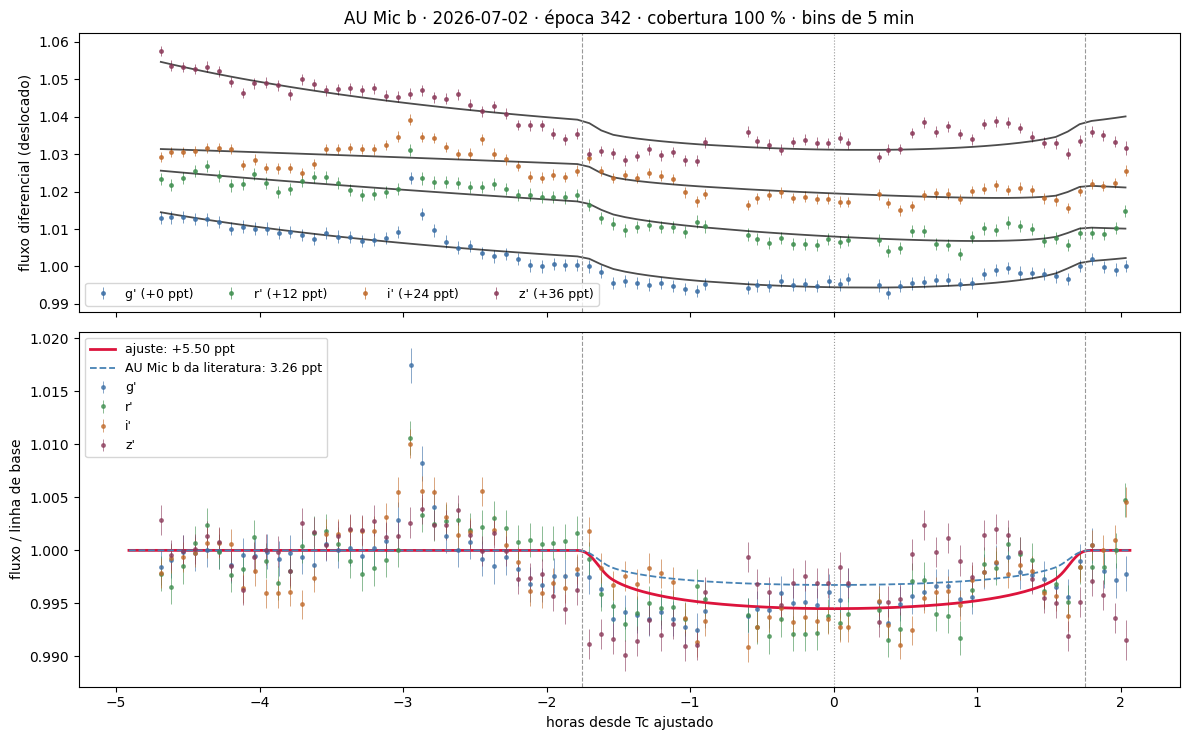

In [18]:
# ═══ 7 · noite 2026-07-02 · AU Mic b, época 342 (trânsito completo) ═════════
# dt_max=15 min: a efeméride acerta Tc com ~2.7 min, então buscar muito além
# disso só deixa o ajuste correr atrás da variabilidade da estrela (com ±30 min
# ele encosta no limite nas duas noites novas).
res_0702 = analisa_noite("20260702", dt_max=15)



── 2026-08-05 · época 346 ────────────────────────────────────────
janela 2461258.46777..2461258.80281 (8.0 h) | Tc previsto 2461258.63860 (03:19:35 UTC) | cobertura 100 %
Tc ajustado 2461258.64832 | O-C = +14.0 min (efeméride ± 2.7) | χ²/ndof = 1.71
profundidade = +4.92 ± 1.34 ppt em g'  (literatura 3.67)  ->  +3.7σ
pontos cortados / bins descartados: g': 926/17 | r': 2127/14 | i': 1981/16 | z': 1976/15


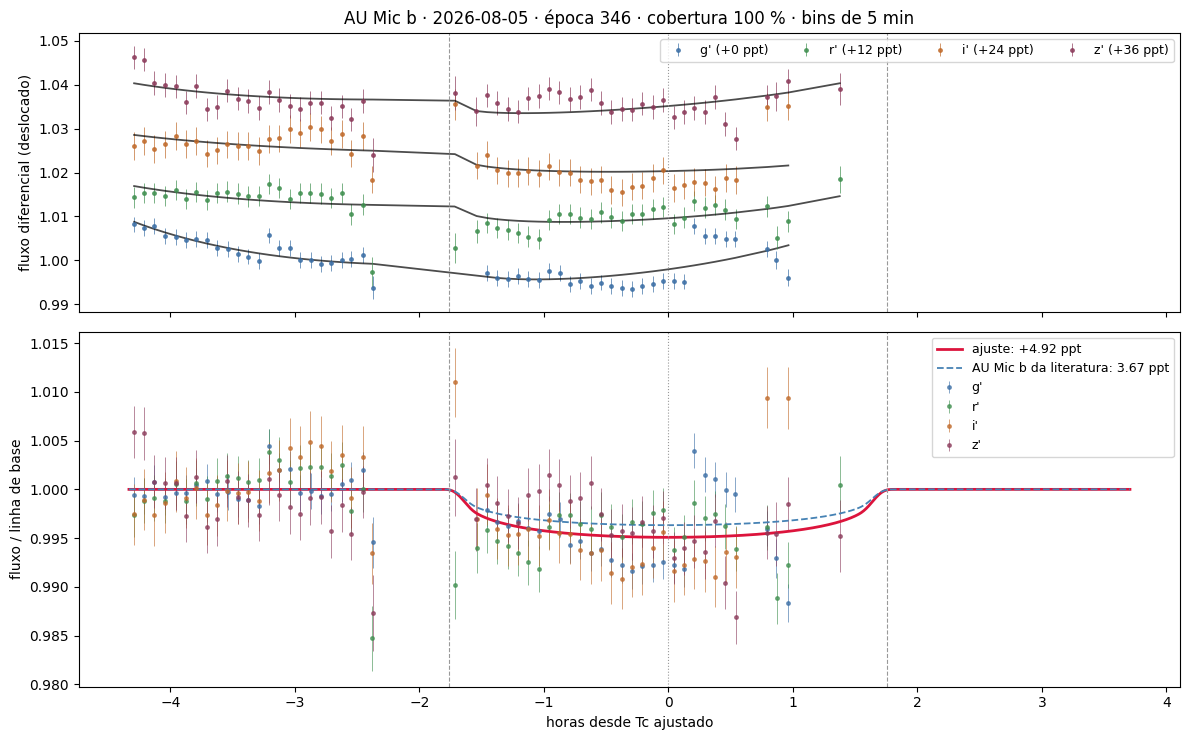

In [9]:
# ═══ 8 · noite 2026-08-05 · AU Mic b, época 346 (trânsito completo) ═════════
res_0805 = analisa_noite("20260805", dt_max=15)



In [ ]:
# ═══ 9 · noite 2026-08-22 · AU Mic b, época 348 (trânsito completo) ═════
# Trânsito inteiro dentro da janela: Tc previsto 2026-08-23 01:33 UTC, dentro de
# 8.4 h de observação (22:16 -> 06:41 UTC), cobertura de 100 % de T14.
#
# Aqui NÃO se bina nada: bin_min=None mantém a cadência original do SPARC4
# (~4 s no canal 1, ~1.3 s nos canais 2-4; ~63 mil pontos no ajuste). Duas
# coisas mudam junto com isso, dentro de analisa_noite:
#   - o modelo batman passa a ser integrado no tempo de exposição real,
#     não num bin de 5 min;
#   - o erro de cada ponto vem do ruído ponto-a-ponto medido (o EMAG formal do
#     pipeline superestima o ruído em ~6x aqui) e é inflado pelo fator beta de
#     ruído correlacionado — sem isso, 63 mil pontos dariam uma barra de erro
#     irreal de ~0.1 ppt.
#
# Como nas outras noites, o Tc livre foge até o limite da varredura: com linha
# de base livre, o instante não é mensurável nesta noite. A medida limpa é a
# profundidade com Tc PRESO na efeméride, na tabela da última célula.
res_0822 = analisa_noite("20260822", bin_min=None, dt_max=15)


In [ ]:
# ═══ 9b · a mesma noite 22/08, agora binada em 1.5 min ══════════════════════
# A célula acima é o dado real, na cadência do instrumento (~4 s / ~1.3 s): é
# ali que o ruído ponto-a-ponto e o beta são medidos. Aqui a MESMA noite é
# refeita com bins de 1.5 min — abaixo dos 2 min pedidos, e ~30x menor que a
# duração do ingresso —, só para o trânsito ficar visível: o ruído branco cai
# por sqrt(N) (~20x no canal 1) sem borrar a forma da curva.
#
# O binning não é só cosmético no ajuste: com bins, o erro de cada ponto passa
# a ser a dispersão interna do bin (que já embute parte do ruído vermelho), e
# o modelo batman é integrado em 1.5 min em vez do tempo de exposição. Por isso
# a profundidade sai parecida, mas não idêntica, à da célula anterior — a
# medida "oficial" continua sendo a da noite sem binning.
res_0822_bin = analisa_noite("20260822", bin_min=1.5, dt_max=15)

b0 = res_0822_bin["bandas"][0]
print()
print(f"── 22/08 · profundidade em {b0}' · sem binning x bins de 1.5 min " + "─" * 12)
for rot, r in [("cadência original", res_0822), ("bins de 1.5 min", res_0822_bin)]:
    p0 = r["prof0"][b0]
    print(f"   {rot:<20s}: {r['delta']*p0*1e3:+.2f} ± {r['e_delta']*p0*1e3:.2f} ppt "
          f"({r['nsig']:+.1f}σ) | {sum(r['dados'][c]['tb'].size for c in r['canais'])} pontos")


,época,cobertura (%),O-C (min),sigma efem (min),prof (ppt),sigma (ppt),esperada (ppt),n sigma,chi2r
noite,,,,,,,,,
2026-07-02,342,100,-15.0,2.7,+5.50,0.61,3.26,+9.1,3.88
2026-07-19,344,90,+6.5,2.7,-1.82,0.89,3.26,-2.0,4.00
2026-08-05,346,100,+14.0,2.7,+4.92,1.34,3.67,+3.7,1.71


── 2026-07-02 · época 342 ────────────────────────────────────────
janela 2461224.57097..2461224.86162 (7.0 h) | Tc previsto 2461224.78598 (06:51:48 UTC) | cobertura 100 %
Tc ajustado 2461224.78563 | O-C = -0.5 min (efeméride ± 2.7) | χ²/ndof = 4.24
profundidade = +4.80 ± 0.68 ppt em g'  (literatura 3.26)  ->  +7.1σ
pontos cortados / bins descartados: g': 36/2 | r': 67/2 | i': 50/2 | z': 22/2
── 2026-07-19 · época 344 ────────────────────────────────────────
janela 2461241.54003..2461241.77071 (5.5 h) | Tc previsto 2461241.71229 (05:05:41 UTC) | cobertura 90 %
Tc ajustado 2461241.71264 | O-C = +0.5 min (efeméride ± 2.7) | χ²/ndof = 3.80
profundidade = -1.25 ± 0.90 ppt em g'  (literatura 3.26)  ->  -1.4σ
pontos cortados / bins descartados: g': 15/0 | r': 47/0 | i': 26/0 | z': 27/0
(profundidade compatível com zero ou negativa: sem detecção)
── 2026-08-05 · época 346 ────────────────────────────────────────
janela 2461258.46777..2461258.80281 (8.0 h) | Tc previsto 2461258.63860 (03:19:35

,época,prof em Tc previsto (ppt),sigma (ppt),esperada (ppt),n sigma,chi2r
noite,,,,,,
2026-07-02,342,+4.80,0.68,3.26,+7.1,4.24
2026-07-19,344,-1.25,0.90,3.26,-1.4,3.80
2026-08-05,346,+4.16,1.16,3.26,+3.6,1.72


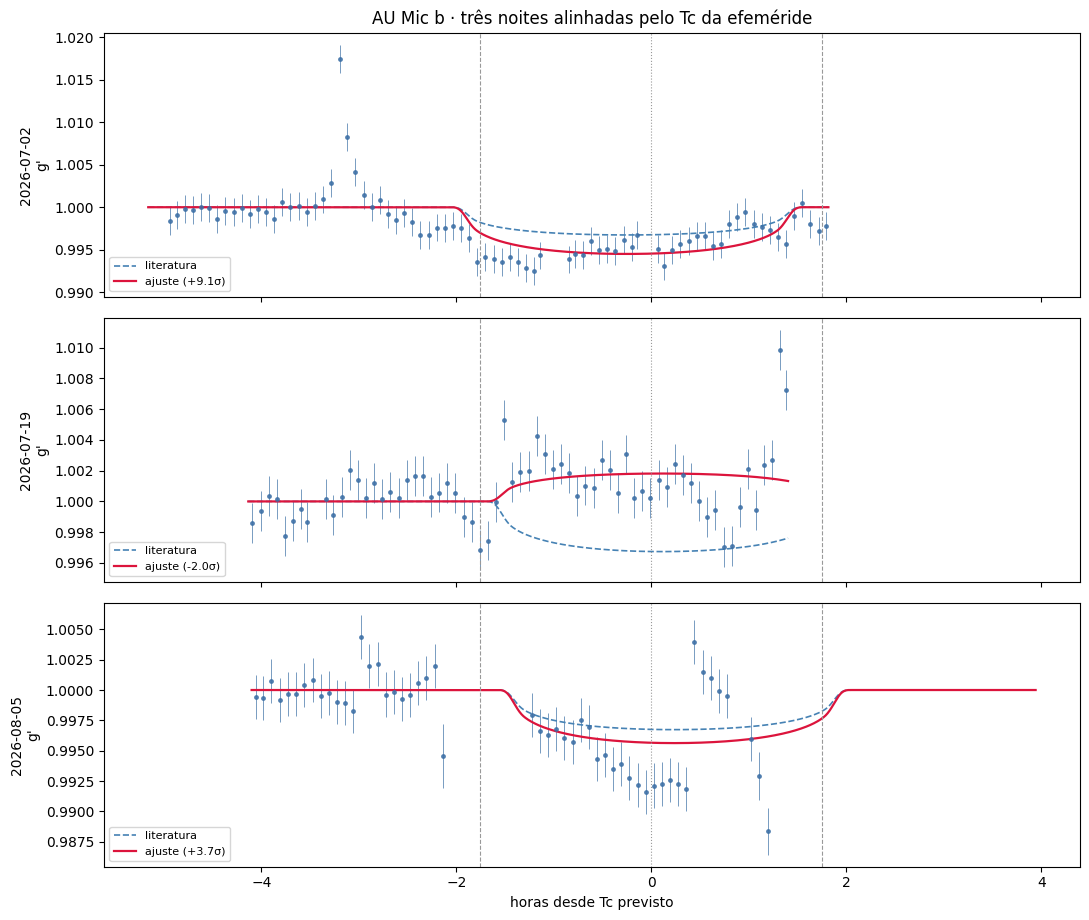

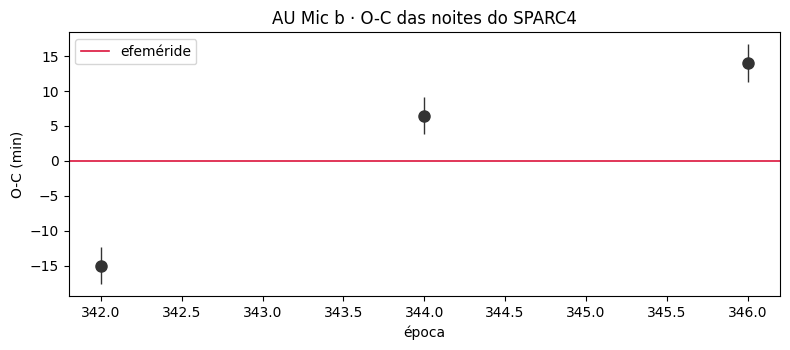

Lembre: onde a profundidade sai negativa ou compatível com zero, o O-C não significa nada — o ajuste não está medindo trânsito nenhum.


In [19]:
# ═══ 10 · as quatro noites lado a lado ═════════════════════════════════════════
import numpy as np, pandas as pd, matplotlib.pyplot as plt

res_0719 = dict(noite=NIGHT, rotulo=NIGHT_LABEL, epoca=EPOCH, tc_efem=TC_EFEM,
                tc_err=TC_ERR, tc_fit=TC_FIT, oc_min=(TC_FIT - TC_EFEM) * 1440,
                cobertura=cob, delta=delta, e_delta=e_delta, prof0=PROF0,
                dchi2=dchi2, nsig=nsig, chi2r=chi2 / ndof, dados=dados,
                bases=bases, canais=chs, bandas=bandas, t1=TSTART, t2=TSTOP,
                bin_min=BIN_MIN, exp_min=BIN_MIN,
                rot_bin=f"bins de {BIN_MIN:.0f} min", beta=1.0, perfil=perfil)

todas = sorted([res_0702, res_0719, res_0805, res_0822], key=lambda r: r["epoca"])

tab_noites = pd.DataFrame([{
    "noite": r["rotulo"], "época": r["epoca"], "amostragem": r["rot_bin"],
    "cobertura (%)": r["cobertura"] * 100,
    "O-C (min)": r["oc_min"],
    "sigma efem (min)": r["tc_err"] * 1440,
    "prof (ppt)": r["delta"] * r["prof0"][r["bandas"][0]] * 1e3,
    "sigma (ppt)": r["e_delta"] * r["prof0"][r["bandas"][0]] * 1e3,
    "esperada (ppt)": r["prof0"][r["bandas"][0]] * 1e3,
    "n sigma": r["nsig"], "chi2r": r["chi2r"],
} for r in todas]).set_index("noite")
display(tab_noites.style.format({"cobertura (%)": "{:.0f}", "O-C (min)": "{:+.1f}",
                                 "sigma efem (min)": "{:.1f}", "prof (ppt)": "{:+.2f}",
                                 "sigma (ppt)": "{:.2f}", "esperada (ppt)": "{:.2f}",
                                 "n sigma": "{:+.1f}", "chi2r": "{:.2f}"}))

# ── a mesma medida com Tc PRESO na efeméride ────────────────────────────────
# Com estas noites o instante não é mensurável (a linha de base absorve
# deslocamentos de dezenas de minutos), mas a PROFUNDIDADE no instante previsto
# é uma medida limpa: é o número a comparar com a literatura.
# cada noite volta com a MESMA amostragem de cima (a de 22/08 segue sem binning)
fixos = [analisa_noite(r["noite"], dt_max=0.5, bin_min=r["bin_min"], mostra=False)
         for r in todas]
tab_fixo = pd.DataFrame([{
    "noite": r["rotulo"], "época": r["epoca"], "amostragem": r["rot_bin"],
    "prof em Tc previsto (ppt)": r["delta"] * r["prof0"][r["bandas"][0]] * 1e3,
    "sigma (ppt)": r["e_delta"] * r["prof0"][r["bandas"][0]] * 1e3,
    "esperada (ppt)": r["prof0"][r["bandas"][0]] * 1e3,
    "n sigma": r["nsig"], "chi2r": r["chi2r"],
} for r in fixos]).set_index("noite")
print("\n── profundidade com Tc fixo na efeméride (g') " + "─" * 25)
display(tab_fixo.style.format({"prof em Tc previsto (ppt)": "{:+.2f}",
                               "sigma (ppt)": "{:.2f}", "esperada (ppt)": "{:.2f}",
                               "n sigma": "{:+.1f}", "chi2r": "{:.2f}"}))

# curvas das quatro noites alinhadas pelo Tc previsto, banda mais limpa (g')
fig, axs = plt.subplots(len(todas), 1, figsize=(11, 3.1 * len(todas)), sharex=True)
axs = np.atleast_1d(axs)
for ax, r in zip(axs, todas):
    ch = r["canais"][0];  b = r["bandas"][0];  d = r["dados"][ch]
    x  = (d["tb"] - r["tc_efem"]) * 24
    ms_, lw_, al_ = (5, .6, .8) if r["bin_min"] is not None else (1.5, 0, .20)
    ax.errorbar(x, d["fb"] / r["bases"][ch], d["eb"], fmt=".", ms=ms_, lw=lw_,
                alpha=al_, color=CORES[b])
    tg = np.linspace(r["t1"], r["t2"], 800)
    ax.plot((tg - r["tc_efem"]) * 24,
            1 - r["perfil"](tg, r["tc_fit"], b), "--", lw=1.2, color="steelblue",
            label="literatura")
    ax.plot((tg - r["tc_efem"]) * 24,
            1 - r["delta"] * r["perfil"](tg, r["tc_fit"], b), "-", lw=1.6,
            color="crimson", label=f"ajuste ({r['nsig']:+.1f}σ)")
    ax.axvline(0, color="0.6", lw=.8, ls=":")
    ax.axvline(-T14 / 2 * 24, color="0.6", lw=.8, ls="--")
    ax.axvline(+T14 / 2 * 24, color="0.6", lw=.8, ls="--")
    ax.set_ylabel(f"{r['rotulo']}\n{b}'")
    ax.legend(fontsize=8, loc="lower left")
axs[0].set_title("AU Mic b · quatro noites alinhadas pelo Tc da efeméride")
axs[-1].set_xlabel("horas desde Tc previsto")
plt.tight_layout();  plt.show()

# O-C das três épocas
plt.figure(figsize=(8, 3.6))
ep = [r["epoca"] for r in todas]
oc = [r["oc_min"] for r in todas]
er = [r["tc_err"] * 1440 for r in todas]
plt.errorbar(ep, oc, er, fmt="o", ms=8, lw=1, color="#333")
plt.axhline(0, color="crimson", lw=1.2, label="efeméride")
plt.xlabel("época");  plt.ylabel("O-C (min)")
plt.title("AU Mic b · O-C das noites do SPARC4")
plt.legend();  plt.tight_layout();  plt.show()
print("Lembre: onde a profundidade sai negativa ou compatível com zero, o O-C "
      "não significa nada — o ajuste não está medindo trânsito nenhum.")
